# 1. Importing Libraries

In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.float_format', lambda x: '%.2f' % x)

print("Libraries imported successfully.")

Libraries imported successfully.


Why?
We need:
- pandas → data manipulation
- numpy → numerical operations
- matplotlib → visualization
- seaborn → statistical visualization

# 2. Data Path

In [14]:
# Data Path 
file_path = r"C:\Users\Deepak\Documents\Deepak Documents\PROJECTS\BANK LOAN ANALYTICS DASHBOARD END TO END PROJECT USING POWER BI\Original Data file\Financial_loan_data.xlsx"

# 3.Load the dataset

In [15]:
import pandas as pd  # Import pandas library and assign it the alias 'pd'

file_path = r"C:\Users\Deepak\Documents\Deepak Documents\PROJECTS\BANK LOAN ANALYTICS DASHBOARD END TO END PROJECT USING POWER BI\Original Data file\Financial_loan_data.xlsx"

df = pd.read_excel(file_path)  # Now pd is defined and can be used

print("Dataset loaded successfully.")

Dataset loaded successfully.


## Production-Style Optimization & Validation Layer

This section extends the original notebook without changing the original analysis.

**Initial approach:** step-by-step cleaning and analysis of the loan dataset.

**Optimization goal:** make repetitive checks reusable, reduce manual processing, and cross-check results before the SQL/Power BI stage.

> Interview framing: the initial end-to-end Python cleaning and analysis workflow took around 2 hours. During validation, an initial result showed a difference of nearly 40% from the validated result. The exact source of that difference should be explained using the actual validation output below; do not describe it as "40% accuracy" unless accuracy was formally calculated.


In [16]:
# Start timing the Python workflow from this point
import time
import numpy as np
import pandas as pd

optimization_start = time.perf_counter()

print(f"Rows: {len(df):,}")
print(f"Columns: {df.shape[1]:,}")


Rows: 38,576
Columns: 23


### 1. Automated data-quality profile

Instead of checking every column manually, generate one reusable profile.


In [17]:
quality_profile = pd.DataFrame({
    "Data_Type": df.dtypes.astype(str),
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (df.isna().mean() * 100).round(2),
    "Unique_Values": df.nunique(dropna=False)
}).sort_values("Missing_Percentage", ascending=False)

display(quality_profile)


,Data_Type,Missing_Count,Missing_Percentage,Unique_Values
EMP_TITLE,object,1438,3.73,28526
ID,int64,0,0.00,38576
ISSUE_DATE,datetime64[us],0,0.00,65
VERIFICATION_STATUS,str,0,0.00,3
GRADE,str,0,0.00,7
HOME_OWNERSHIP,str,0,0.00,5
PURPOSE,str,0,0.00,14
ADDRESS_STATE,str,0,0.00,50
LOAN_STATUS,str,0,0.00,3
EMP_LENGTH,str,0,0.00,11


### 2. Automated validation checks

These checks make the cleaning process repeatable and auditable.


In [18]:
validation_results = {
    "Total Rows": len(df),
    "Duplicate Rows": int(df.duplicated().sum()),
    "Duplicate Loan IDs": int(df["ID"].duplicated().sum()) if "ID" in df.columns else None,
    "Missing Values": int(df.isna().sum().sum()),
    "Negative Loan Amounts": int((df["LOAN_AMOUNT"] < 0).sum()) if "LOAN_AMOUNT" in df.columns else None,
    "Negative DTI": int((df["DTI"] < 0).sum()) if "DTI" in df.columns else None,
    "Negative Interest Rates": int((df["INT_RATE"] < 0).sum()) if "INT_RATE" in df.columns else None,
}

validation_report = pd.DataFrame(
    validation_results.items(),
    columns=["Validation Check", "Result"]
)

display(validation_report)


,Validation Check,Result
0,Total Rows,38576
1,Duplicate Rows,0
2,Duplicate Loan IDs,0
3,Missing Values,1438
4,Negative Loan Amounts,0
5,Negative DTI,0
6,Negative Interest Rates,0


### 3. Vectorized loan-quality flags

Create reusable numeric flags once, rather than repeatedly evaluating text conditions during analysis.


In [19]:
if "LOAN_STATUS" in df.columns:
    df["IS_BAD_LOAN"] = df["LOAN_STATUS"].eq("Charged Off").astype("int8")
    df["IS_GOOD_LOAN"] = df["LOAN_STATUS"].isin(
        ["Fully Paid", "Current"]
    ).astype("int8")

    print("Bad loans:", int(df["IS_BAD_LOAN"].sum()))
    print("Good loans:", int(df["IS_GOOD_LOAN"].sum()))
else:
    print("LOAN_STATUS column not found; flags were not created.")


Bad loans: 5333
Good loans: 33243


### 4. Reusable risk-analysis function

Use one function for grade, DTI, loan amount, or interest-rate segmentation.


In [20]:
def risk_analysis(data, segment_column):
    if segment_column not in data.columns:
        raise KeyError(f"{segment_column!r} is not present in the dataframe.")

    result = (
        data.groupby(segment_column, observed=True)
            .agg(
                Applications=("ID", "count"),
                Funded_Amount=("LOAN_AMOUNT", "sum"),
                Bad_Loans=("IS_BAD_LOAN", "sum")
            )
            .reset_index()
    )

    result["Bad_Loan_Rate"] = (
        result["Bad_Loans"] / result["Applications"] * 100
    ).round(2)

    return result.sort_values("Bad_Loan_Rate", ascending=False)

# Example:
# risk_analysis(df, "GRADE")


### 5. Quantify the validation difference

If you have an initial result and a validated result for the same metric, calculate the percentage difference instead of calling it "accuracy".


In [21]:
def percentage_difference(initial_value, validated_value):
    if validated_value == 0:
        return np.nan
    return abs(initial_value - validated_value) / abs(validated_value) * 100

# Example usage:
# initial_bad_rate = 0.20
# validated_bad_rate = 0.3333
# difference = percentage_difference(initial_bad_rate, validated_bad_rate)
# print(f"Percentage difference: {difference:.2f}%")

print("Use this calculation only with the actual initial and validated values from your analysis.")


Use this calculation only with the actual initial and validated values from your analysis.


### 6. Optional risk segmentation

These segments can be reused in multiple analyses without recreating the logic each time.


In [22]:
if "DTI" in df.columns:
    df["DTI_SEGMENT"] = pd.qcut(
        df["DTI"],
        q=4,
        labels=["Low", "Medium-Low", "Medium-High", "High"],
        duplicates="drop"
    )

if "LOAN_AMOUNT" in df.columns:
    df["LOAN_AMOUNT_SEGMENT"] = pd.qcut(
        df["LOAN_AMOUNT"],
        q=4,
        labels=["Low", "Medium-Low", "Medium-High", "High"],
        duplicates="drop"
    )

if "INT_RATE" in df.columns:
    df["INTEREST_RATE_SEGMENT"] = pd.qcut(
        df["INT_RATE"],
        q=4,
        labels=["Low", "Medium-Low", "Medium-High", "High"],
        duplicates="drop"
    )

print("Risk segmentation completed.")


Risk segmentation completed.


### 7. Runtime measurement

This measures actual Python execution time for the optimization section. It should not be presented as the manual effort saved.


In [23]:
optimization_end = time.perf_counter()
optimization_runtime_minutes = (optimization_end - optimization_start) / 60

print(
    f"Optimization/validation section runtime: "
    f"{optimization_runtime_minutes:.2f} minutes"
)


Optimization/validation section runtime: 0.03 minutes


### Interview explanation

> "Initially, I approached the bank-loan project step by step. I loaded the data, understood the business fields, cleaned the data, validated it, and performed exploratory analysis in Python. That initial workflow took me around two hours. During validation, I noticed a substantial difference—nearly 40% in one of the initial results—so I did not treat the first result as final. I introduced automated validation checks, vectorized Pandas/NumPy operations, reusable analysis functions, and cross-validation with SQL before moving the results into Power BI.

**Important:** say "nearly 40% difference" only for the specific metric where you can show the initial and validated values. Do not call it "40% accuracy" unless you have a formal accuracy calculation.


In [24]:
# Start pipeline timer
import time

pipeline_start = time.perf_counter()

print(f"Dataset loaded: {len(df):,} rows × {df.shape[1]} columns")

Dataset loaded: 38,576 rows × 28 columns


In [25]:
df.head()

,ISSUE_DATE,ID,PURPOSE,VERIFICATION_STATUS,GRADE,HOME_OWNERSHIP,ADDRESS_STATE,LOAN_STATUS,EMP_LENGTH,EMP_TITLE,LAST_CREDIT_PULL_DATE,LAST_PAYMENT_DATE,NEXT_PAYMENT_DATE,MEMBER_ID,SUB_GRADE,TERM,ANNUAL_INCOME,DTI,INSTALLMENT,INT_RATE,LOAN_AMOUNT,TOTAL_ACC,TOTAL_PAYMENT,IS_BAD_LOAN,IS_GOOD_LOAN,DTI_SEGMENT,LOAN_AMOUNT_SEGMENT,INTEREST_RATE_SEGMENT
0,2021-01-01,1072053,car,Source Verified,E,RENT,CA,Fully Paid,9 years,MKC Accounting,2021-12-14,2021-01-15,2021-02-15,1288686,E1,36 months,48000.00,0.05,109.43,0.19,3000,4,3939,0,1,Low,Low,High
1,2021-01-01,1068350,car,Verified,A,MORTGAGE,IL,Fully Paid,10+ years,J&J Steel Inc,2021-12-14,2021-01-15,2021-02-15,1302971,A1,36 months,83000.00,0.02,106.53,0.06,3500,28,3835,0,1,Low,Low,Low
2,2021-01-05,1069243,car,Not Verified,C,RENT,CA,Charged Off,4 years,Chemat Technology Inc,2021-12-12,2021-01-09,2021-02-09,1304116,C5,36 months,50000.00,0.21,421.65,0.16,12000,11,3522,1,0,High,Medium-High,High
3,2021-01-08,207910,car,Not Verified,A,MORTGAGE,FL,Charged Off,< 1 year,NaN,2021-05-16,2021-02-10,2021-03-10,183496,A2,36 months,120000.00,0.08,69.14,0.07,2225,20,2508,1,0,Low,Low,Low
4,2021-01-08,211723,car,Not Verified,C,OWN,MD,Charged Off,4 years,self employed,2021-12-09,2021-08-08,2021-09-08,211606,C2,36 months,72000.00,0.05,262.26,0.11,8000,8,2135,1,0,Low,Medium-Low,Medium-Low


In [26]:
df.tail()

,ISSUE_DATE,ID,PURPOSE,VERIFICATION_STATUS,GRADE,HOME_OWNERSHIP,ADDRESS_STATE,LOAN_STATUS,EMP_LENGTH,EMP_TITLE,LAST_CREDIT_PULL_DATE,LAST_PAYMENT_DATE,NEXT_PAYMENT_DATE,MEMBER_ID,SUB_GRADE,TERM,ANNUAL_INCOME,DTI,INSTALLMENT,INT_RATE,LOAN_AMOUNT,TOTAL_ACC,TOTAL_PAYMENT,IS_BAD_LOAN,IS_GOOD_LOAN,DTI_SEGMENT,LOAN_AMOUNT_SEGMENT,INTEREST_RATE_SEGMENT
38571,2021-12-11,1048887,wedding,Verified,F,MORTGAGE,OH,Charged Off,2 years,"CINCINNATI CHILDREN""S HOSPITAL",2021-05-16,2021-05-12,2021-06-12,1280067,F3,60 months,73174.40,0.08,647.39,0.22,23600,17,24397,1,0,Low,High,High
38572,2021-12-11,1036857,wedding,Verified,D,RENT,NY,Charged Off,10+ years,Supreme Court,2021-07-13,2021-03-13,2021-04-13,1266739,D5,60 months,86779.00,0.18,612.72,0.18,24000,35,9735,1,0,Medium-High,High,High
38573,2021-12-11,1026558,wedding,Verified,B,MORTGAGE,CA,Fully Paid,4 years,"ACCES I/O Products, Inc.",2021-10-14,2021-09-14,2021-10-14,1255948,B4,60 months,54600.00,0.12,561.44,0.12,25000,19,31693,0,1,Medium-Low,High,Medium-High
38574,2021-12-11,1052169,wedding,Verified,C,RENT,NY,Fully Paid,1 year,Binder and Binder,2021-01-12,2021-01-12,2021-02-12,1283716,C1,60 months,50000.00,0.19,460.10,0.13,20000,39,20226,0,1,High,High,Medium-High
38575,2021-12-12,1059497,car,Verified,B,MORTGAGE,FL,Fully Paid,10+ years,Sandestin Beach Hilton,2021-12-14,2021-12-14,2022-01-14,1291322,B2,36 months,35000.00,0.14,162.87,0.11,5000,23,5863,0,1,Medium-High,Low,Medium-Low


# 4. Understand the dataset

In [27]:
print("Number of Rows:", df.shape[0])
print("Number of Columns:", df.shape[1])

Number of Rows: 38576
Number of Columns: 28


So our dataset contains:
38,576 loan applications and 23 attributes.

# 5. Column names

In [28]:
df.columns.tolist()

['ISSUE_DATE',
 'ID',
 'PURPOSE',
 'VERIFICATION_STATUS',
 'GRADE',
 'HOME_OWNERSHIP',
 'ADDRESS_STATE',
 'LOAN_STATUS',
 'EMP_LENGTH',
 'EMP_TITLE',
 'LAST_CREDIT_PULL_DATE',
 'LAST_PAYMENT_DATE',
 'NEXT_PAYMENT_DATE',
 'MEMBER_ID',
 'SUB_GRADE',
 'TERM',
 'ANNUAL_INCOME',
 'DTI',
 'INSTALLMENT',
 'INT_RATE',
 'LOAN_AMOUNT',
 'TOTAL_ACC',
 'TOTAL_PAYMENT',
 'IS_BAD_LOAN',
 'IS_GOOD_LOAN',
 'DTI_SEGMENT',
 'LOAN_AMOUNT_SEGMENT',
 'INTEREST_RATE_SEGMENT']

# 6. Dataset information

In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 38576 entries, 0 to 38575
Data columns (total 28 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   ISSUE_DATE             38576 non-null  datetime64[us]
 1   ID                     38576 non-null  int64         
 2   PURPOSE                38576 non-null  str           
 3   VERIFICATION_STATUS    38576 non-null  str           
 4   GRADE                  38576 non-null  str           
 5   HOME_OWNERSHIP         38576 non-null  str           
 6   ADDRESS_STATE          38576 non-null  str           
 7   LOAN_STATUS            38576 non-null  str           
 8   EMP_LENGTH             38576 non-null  str           
 9   EMP_TITLE              37138 non-null  object        
 10  LAST_CREDIT_PULL_DATE  38576 non-null  datetime64[us]
 11  LAST_PAYMENT_DATE      38576 non-null  datetime64[us]
 12  NEXT_PAYMENT_DATE      38576 non-null  datetime64[us]
 13  MEMBER_ID   

What we are checking
This tells us:
- number of records
- column names
- data types
- non-null values
- memory usage
The important data types in our dataset are already appropriate:

Column Type	Examples

Date: ISSUE_DATE, LAST_PAYMENT_DATE

Integer: ID, LOAN_AMOUNT, TOTAL_PAYMENT

Float: ANNUAL_INCOME, DTI, INT_RATE

Categorical/Text: PURPOSE, GRADE, LOAN_STATUS

So we don't need to blindly convert every column.

# 7. Statistical overview

In [30]:
df.describe().T

,count,mean,min,25%,50%,75%,max,std
ISSUE_DATE,38576,2021-07-16 02:31:35.562007,2021-01-01 00:00:00,2021-04-11 00:00:00,2021-07-11 00:00:00,2021-10-11 00:00:00,2021-12-12 00:00:00,NaN
ID,38576.00,681037.06,54734.00,513517.00,662728.00,836506.00,1077501.00,211324.58
LAST_CREDIT_PULL_DATE,38576,2021-06-08 13:36:34.193280,2021-01-08 00:00:00,2021-04-15 00:00:00,2021-05-16 00:00:00,2021-08-13 00:00:00,2022-01-20 00:00:00,NaN
LAST_PAYMENT_DATE,38576,2021-06-26 09:52:08.909166,2021-01-08 00:00:00,2021-03-16 00:00:00,2021-06-14 00:00:00,2021-09-15 00:00:00,2021-12-15 00:00:00,NaN
NEXT_PAYMENT_DATE,38576,2021-07-26 20:42:20.605557,2021-02-08 00:00:00,2021-04-16 00:00:00,2021-07-14 00:00:00,2021-10-15 00:00:00,2022-01-15 00:00:00,NaN
MEMBER_ID,38576.00,847651.51,70699.00,662978.75,847356.50,1045652.50,1314167.00,266810.46
ANNUAL_INCOME,38576.00,69644.54,4000.00,41500.00,60000.00,83200.50,6000000.00,64293.68
DTI,38576.00,0.13,0.00,0.08,0.13,0.19,0.30,0.07
INSTALLMENT,38576.00,326.86,15.69,168.45,283.05,434.44,1305.19,209.09
INT_RATE,38576.00,0.12,0.05,0.09,0.12,0.15,0.25,0.04


This is important because it gives:
- count
- mean
- standard deviation
- minimum
- 25th percentile
- median
- 75th percentile
- maximum
For example, we found:
Metric	           Mean                 	Minimum	                                       Maximum
Annual Income	69,644.54	        4,000	                                       6,000,000
DTI	13.33%	0%	29.99%
Interest Rate	12.05%	5.42%	24.59%
Loan Amount	11,296.07	500	35,000
Installment	326.86	15.69	1,305.19
Total Payment	12,263.35	34	58,564


These numbers already give us some useful business context.

# 8. Missing-value analysis
Now let's properly investigate missing data.

In [31]:
missing_count = df.isnull().sum()

missing_percentage = (
    df.isnull().sum() / len(df) * 100
)

missing_summary = pd.DataFrame({
    'Missing_Count': missing_count,
    'Missing_Percentage': missing_percentage
})

missing_summary = (
    missing_summary
    .sort_values('Missing_Count', ascending=False)
)

missing_summary

,Missing_Count,Missing_Percentage
EMP_TITLE,1438,3.73
ISSUE_DATE,0,0.00
PURPOSE,0,0.00
ID,0,0.00
VERIFICATION_STATUS,0,0.00
GRADE,0,0.00
ADDRESS_STATE,0,0.00
HOME_OWNERSHIP,0,0.00
LOAN_STATUS,0,0.00
EMP_LENGTH,0,0.00


Actual finding
Only one column has missing values:
EMP_TITLE

There are:
1,438 missing values

That represents approximately:
3.73%

of the dataset.
All other columns have 0 missing values.

# 9. Should we delete those 1,438 records?
No.
This is an important Data Analyst decision.
We should not remove entire loan applications just because EMP_TITLE is missing.
Why?
Because those customers still have valuable information:
- loan amount
- income
- interest rate
- DTI
- loan status
- repayment
- state
- grade
- purpose
Deleting them would unnecessarily reduce the dataset.
Instead:

In [32]:
df['EMP_TITLE'] = df['EMP_TITLE'].fillna('Unknown')

In [33]:
df['EMP_TITLE'].isnull().sum()

np.int64(0)

"I found missing values only in the employment title field. Since employment title is not required for the core portfolio KPIs and removing those records would result in unnecessary data loss, I retained the records and categorized missing employment titles as 'Unknown'."

# 10. Duplicate analysis

In [34]:
duplicate_rows = df.duplicated().sum()

print("Duplicate Rows:", duplicate_rows)

Duplicate Rows: 0


In [35]:
# Now check loan IDs:
duplicate_ids = df['ID'].duplicated().sum()

print("Duplicate Loan IDs:", duplicate_ids)

Duplicate Loan IDs: 0


In [36]:
# check member IDs:
duplicate_members = df['MEMBER_ID'].duplicated().sum()

print("Duplicate Member IDs:", duplicate_members)

Duplicate Member IDs: 0


This is very important because ID represents the loan application.

So our dataset appears to have a one-to-one relationship between loan application and member.

# 11. Data type validation
Let's explicitly check the types:

In [37]:
df.dtypes

ISSUE_DATE               datetime64[us]
ID                                int64
PURPOSE                             str
VERIFICATION_STATUS                 str
GRADE                               str
HOME_OWNERSHIP                      str
ADDRESS_STATE                       str
LOAN_STATUS                         str
EMP_LENGTH                          str
EMP_TITLE                        object
LAST_CREDIT_PULL_DATE    datetime64[us]
LAST_PAYMENT_DATE        datetime64[us]
NEXT_PAYMENT_DATE        datetime64[us]
MEMBER_ID                         int64
SUB_GRADE                           str
TERM                                str
ANNUAL_INCOME                   float64
DTI                             float64
INSTALLMENT                     float64
INT_RATE                        float64
LOAN_AMOUNT                       int64
TOTAL_ACC                         int64
TOTAL_PAYMENT                     int64
IS_BAD_LOAN                        int8
IS_GOOD_LOAN                       int8


In [38]:
# Identify columns by type:
numeric_columns = df.select_dtypes(
    include=['int64', 'float64']
).columns.tolist()

# Explicitly pass 'str' alongside 'object' to silence the warning
categorical_columns = df.select_dtypes(
    include=['object', 'str', 'string']
).columns.tolist()

date_columns = df.select_dtypes(
    include=['datetime64[ns]']
).columns.tolist()

print("Numeric Columns:")
print(numeric_columns)

print("\nCategorical Columns:")
print(categorical_columns)

print("\nDate Columns:")
print(date_columns)

Numeric Columns:
['ID', 'MEMBER_ID', 'ANNUAL_INCOME', 'DTI', 'INSTALLMENT', 'INT_RATE', 'LOAN_AMOUNT', 'TOTAL_ACC', 'TOTAL_PAYMENT']

Categorical Columns:
['PURPOSE', 'VERIFICATION_STATUS', 'GRADE', 'HOME_OWNERSHIP', 'ADDRESS_STATE', 'LOAN_STATUS', 'EMP_LENGTH', 'EMP_TITLE', 'SUB_GRADE', 'TERM']

Date Columns:
['ISSUE_DATE', 'LAST_CREDIT_PULL_DATE', 'LAST_PAYMENT_DATE', 'NEXT_PAYMENT_DATE']


we don't want to assume that Excel data types are correct.

# 12. Check categorical columns
Now we investigate every major categorical field.

In [39]:
categorical_columns = [
    'PURPOSE',
    'VERIFICATION_STATUS',
    'GRADE',
    'HOME_OWNERSHIP',
    'ADDRESS_STATE',
    'LOAN_STATUS',
    'EMP_LENGTH',
    'TERM'
]

for col in categorical_columns:
    print("\n" + "="*60)
    print(col)
    print("="*60)
    print("Unique Values:", df[col].nunique())
    print(df[col].value_counts())


PURPOSE
Unique Values: 14
PURPOSE
Debt consolidation    18214
credit card            4998
other                  3824
home improvement       2876
major purchase         2110
small business         1776
car                    1497
wedding                 928
medical                 667
moving                  559
house                   366
vacation                352
educational             315
renewable_energy         94
Name: count, dtype: int64

VERIFICATION_STATUS
Unique Values: 3
VERIFICATION_STATUS
Not Verified       16464
Verified           12335
Source Verified     9777
Name: count, dtype: int64

GRADE
Unique Values: 7
GRADE
B    11674
A     9689
C     7904
D     5182
E     2786
F     1028
G      313
Name: count, dtype: int64

HOME_OWNERSHIP
Unique Values: 5
HOME_OWNERSHIP
RENT        18439
MORTGAGE    17198
OWN          2838
OTHER          98
NONE            3
Name: count, dtype: int64

ADDRESS_STATE
Unique Values: 50
ADDRESS_STATE
CA    6894
NY    3701
FL    2773
TX    2664


This gives us the actual business distribution.

# 13. Purpose analysis

In [40]:
df['PURPOSE'].value_counts()

PURPOSE
Debt consolidation    18214
credit card            4998
other                  3824
home improvement       2876
major purchase         2110
small business         1776
car                    1497
wedding                 928
medical                 667
moving                  559
house                   366
vacation                352
educational             315
renewable_energy         94
Name: count, dtype: int64

We have 14 loan purposes.

Debt consolidation is the dominant reason for borrowing.

# 14. Loan status analysis

In [41]:
df['LOAN_STATUS'].value_counts()

LOAN_STATUS
Fully Paid     32145
Charged Off     5333
Current         1098
Name: count, dtype: int64

We will later use:
Fully Paid + Current = Good Loan
Charged Off = Bad Loan

But we should not create this classification until we finish the raw-data validation.

# 15. Grade validation

In [42]:
df['GRADE'].value_counts().sort_index()

GRADE
A     9689
B    11674
C     7904
D     5182
E     2786
F     1028
G      313
Name: count, dtype: int64

In [43]:
df['SUB_GRADE'].nunique()

35

In [44]:
df['SUB_GRADE'].value_counts().sort_index()

SUB_GRADE
A1    1052
A2    1440
A3    1740
A4    2803
A5    2654
B1    1751
B2    1990
B3    2834
B4    2455
B5    2644
C1    2089
C2    1972
C3    1490
C4    1202
C5    1151
D1     913
D2    1314
D3    1144
D4     960
D5     851
E1     750
E2     640
E3     538
E4     448
E5     410
F1     325
F2     243
F3     182
F4     163
F5     115
G1     101
G2      78
G3      48
G4      56
G5      30
Name: count, dtype: int64

This allows us to later analyze risk at a more granular level.

# 16. Home ownership validation

In [45]:
df['HOME_OWNERSHIP'].value_counts()

HOME_OWNERSHIP
RENT        18439
MORTGAGE    17198
OWN          2838
OTHER          98
NONE            3
Name: count, dtype: int64

Only three records have NONE.
We should not delete them because there is no evidence that they are invalid.

# 17. Employment length

In [46]:
df['EMP_LENGTH'].value_counts()

EMP_LENGTH
10+ years    8870
< 1 year     4575
2 years      4382
3 years      4088
4 years      3428
5 years      3273
1 year       3229
6 years      2228
7 years      1772
8 years      1476
9 years      1255
Name: count, dtype: int64

This is valid, but we'll eventually transform this column into a numeric representation for analysis.
< 1 year  → 0
1 year    → 1
2 years   → 2
...
10+ years → 10
But don't overwrite the original column.
We'll create:
EMP_LENGTH_YEARS


later.
That's an important data-engineering principle:
Keep the original field and create a transformed analytical field.

# 18. TERM cleaning

In [47]:
df['TERM'].unique()

<ArrowStringArray>
[' 36 months', ' 60 months']
Length: 2, dtype: str

There is a leading space.
This is a small but real data-quality issue.

In [48]:
df['TERM'] = df['TERM'].str.strip()
df['TERM'].unique()

<ArrowStringArray>
['36 months', '60 months']
Length: 2, dtype: str

# 19. Check all text columns for leading/trailing spaces
Instead of manually checking every column:

In [49]:
# Pass both 'object' and 'string' (or 'str') to select string-like columns
text_columns = df.select_dtypes(include=['object', 'string']).columns

for col in text_columns:
    df[col] = df[col].str.strip()

In [50]:
df['TERM'].unique()

<ArrowStringArray>
['36 months', '60 months']
Length: 2, dtype: str

This protects us against hidden whitespace in other categorical fields.

# 20. Date analysis
Now we investigate the date fields.

In [51]:
date_columns = [
    'ISSUE_DATE',
    'LAST_CREDIT_PULL_DATE',
    'LAST_PAYMENT_DATE',
    'NEXT_PAYMENT_DATE'
]

for col in date_columns:
    print(
        col,
        "->",
        df[col].min(),
        "to",
        df[col].max()
    )

ISSUE_DATE -> 2021-01-01 00:00:00 to 2021-12-12 00:00:00
LAST_CREDIT_PULL_DATE -> 2021-01-08 00:00:00 to 2022-01-20 00:00:00
LAST_PAYMENT_DATE -> 2021-01-08 00:00:00 to 2021-12-15 00:00:00
NEXT_PAYMENT_DATE -> 2021-02-08 00:00:00 to 2022-01-15 00:00:00


Actual date ranges
ISSUE_DATE:
2021-01-01 → 2021-12-12

So this portfolio contains approximately one year of loan issuance activity.

# 21. Important date validation
Now we ask:
Is the last payment date always after the issue date?

In [52]:
invalid_payment_dates = (
    df['LAST_PAYMENT_DATE'] < df['ISSUE_DATE']
).sum()

print("Invalid Payment Dates:", invalid_payment_dates)

Invalid Payment Dates: 15453


This looks alarming at first.
But don't immediately delete these rows.
Why?
Because LAST_PAYMENT_DATE can represent the most recent payment recorded, and depending on loan status / source-system logic, a loan may have an issue date later than the last payment date recorded in the dataset.
This is a business-rule validation issue, not automatically a data-entry error.

# 22. Another date validation
Check credit pull:

In [53]:
invalid_credit_pull = (
    df['LAST_CREDIT_PULL_DATE'] < df['ISSUE_DATE']
).sum()

print("Credit Pull Before Issue Date:", invalid_credit_pull)

Credit Pull Before Issue Date: 20182


Again, this shouldn't automatically be treated as an error.
A credit report can be pulled before a loan is issued as part of the underwriting process.
So this is actually business logically possible.

A date relationship that looks unusual statistically isn't necessarily bad data. Always validate it against the business process before deleting records.

# 23. Next payment validation
Check:

In [54]:
invalid_next_payment = (
    df['NEXT_PAYMENT_DATE'] < df['LAST_PAYMENT_DATE']
).sum()

print("Next Payment Before Last Payment:", invalid_next_payment)

Next Payment Before Last Payment: 0


This relationship is logically consistent.

# 24. Numerical validation

In [55]:
numeric_columns = [
    'ANNUAL_INCOME',
    'DTI',
    'INSTALLMENT',
    'INT_RATE',
    'LOAN_AMOUNT',
    'TOTAL_ACC',
    'TOTAL_PAYMENT'
]

In [56]:
df[numeric_columns].min()

ANNUAL_INCOME   4000.00
DTI                0.00
INSTALLMENT       15.69
INT_RATE           0.05
LOAN_AMOUNT      500.00
TOTAL_ACC          2.00
TOTAL_PAYMENT     34.00
dtype: float64

We need to ensure that important financial metrics aren't negative.

In [57]:
for col in numeric_columns:
    print(
        col,
        "Negative values:",
        (df[col] < 0).sum()
    )

ANNUAL_INCOME Negative values: 0
DTI Negative values: 0
INSTALLMENT Negative values: 0
INT_RATE Negative values: 0
LOAN_AMOUNT Negative values: 0
TOTAL_ACC Negative values: 0
TOTAL_PAYMENT Negative values: 0


There are no negative values in these important financial fields.

# 25. Validate DTI
DTI should normally be expressed as a ratio or percentage.
Our dataset stores it as a decimal.

In [58]:
print(df['DTI'].min())
print(df['DTI'].max())

0.0
0.2999


0 → 0.2999 So the maximum DTI is:29.99%

# 26. Validate interest rate

In [59]:
print(df['INT_RATE'].min())
print(df['INT_RATE'].max())
# 5.42% → 24.59%

0.0542
0.2459


In [60]:
df['INT_RATE'].mean()
# 12.05%

np.float64(0.12048831397760262)

# 27. Outlier analysis
Now we reach an important topic.
Outlier does not mean error.
We need to identify unusual observations and then decide whether they are valid.
We'll use the IQR method.

In [61]:
def outlier_summary(data, column):
    
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    outliers = data[
        (data[column] < lower_bound) |
        (data[column] > upper_bound)
    ]
    
    return {
        'Column': column,
        'Q1': Q1,
        'Q3': Q3,
        'IQR': IQR,
        'Lower_Bound': lower_bound,
        'Upper_Bound': upper_bound,
        'Outlier_Count': len(outliers),
        'Outlier_Percentage': len(outliers) / len(data) * 100
    }

In [62]:
outlier_results = []

for col in numeric_columns:
    outlier_results.append(
        outlier_summary(df, col)
    )

outlier_df = pd.DataFrame(outlier_results)

outlier_df

,Column,Q1,Q3,IQR,Lower_Bound,Upper_Bound,Outlier_Count,Outlier_Percentage
0,ANNUAL_INCOME,41500.00,83200.50,41700.50,-21050.75,145751.25,1824,4.73
1,DTI,0.08,0.19,0.10,-0.07,0.34,0,0.00
2,INSTALLMENT,168.45,434.44,265.99,-230.54,833.43,1150,2.98
3,INT_RATE,0.09,0.15,0.05,0.01,0.22,78,0.20
4,LOAN_AMOUNT,5500.00,15000.00,9500.00,-8750.00,29250.00,1208,3.13
5,TOTAL_ACC,14.00,29.00,15.00,-8.50,51.50,692,1.79
6,TOTAL_PAYMENT,5633.00,16658.00,11025.00,-10904.50,33195.50,1277,3.31


# 28. What we found
The IQR method identifies observations outside the statistical range.
Approximate results:
Column	Outliers
Annual Income	1,824
DTI	0
Installment	1,150
Interest Rate	78
Loan Amount	1,208
Total Accounts	692
Total Payment	1,277


But we will not remove these outliers.
Why?
For example:
Annual Income = $6,000,000

is statistically unusual, but it could represent a genuine high-income borrower.
Likewise:
Loan Amount = $35,000

is not necessarily an error.

"I identified statistical outliers using the IQR method, but I retained them because they represent potentially valid financial observations and there was no business rule confirming them as erroneous."

# 29. Boxplot analysis
Let's visually inspect the major numerical fields.

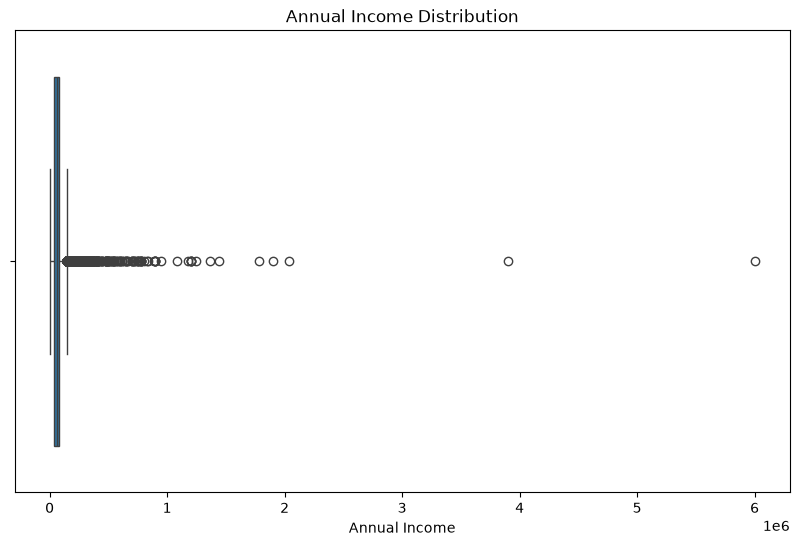

In [63]:
plt.figure(figsize=(10, 6))

sns.boxplot(x=df['ANNUAL_INCOME'])

plt.title('Annual Income Distribution')
plt.xlabel('Annual Income')

plt.show()

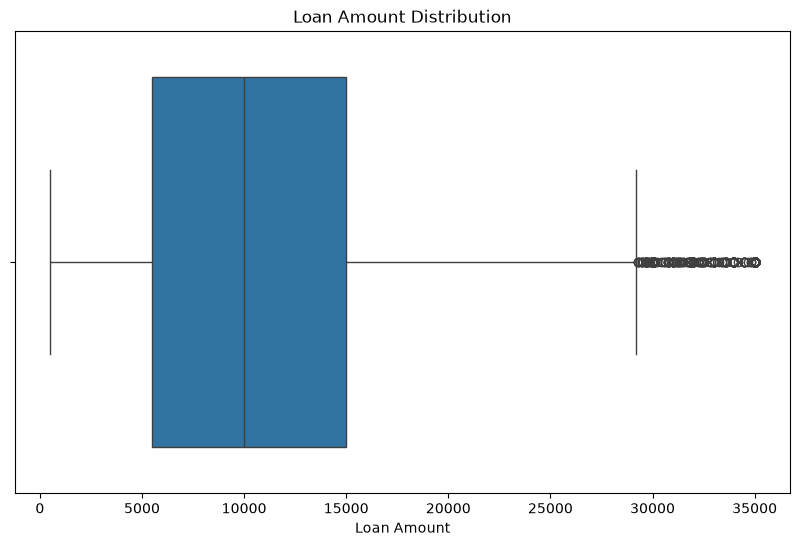

In [64]:
# Loan amount:
plt.figure(figsize=(10, 6))

sns.boxplot(x=df['LOAN_AMOUNT'])

plt.title('Loan Amount Distribution')
plt.xlabel('Loan Amount')

plt.show()

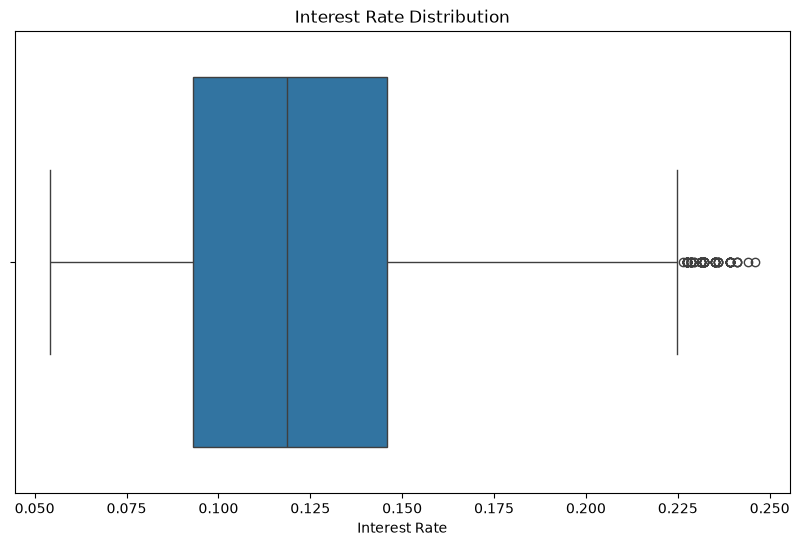

In [65]:
# Interest rate:
plt.figure(figsize=(10, 6))

sns.boxplot(x=df['INT_RATE'])

plt.title('Interest Rate Distribution')
plt.xlabel('Interest Rate')

plt.show()

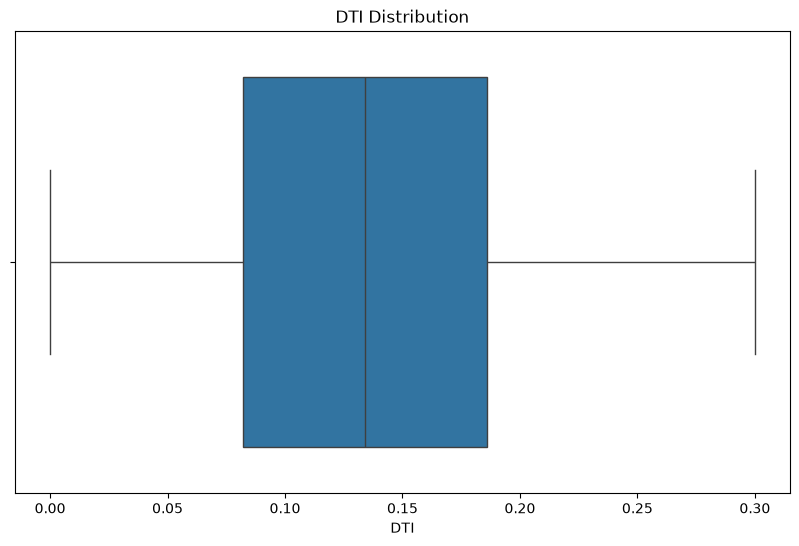

In [66]:
# DTI:
plt.figure(figsize=(10, 6))

sns.boxplot(x=df['DTI'])

plt.title('DTI Distribution')
plt.xlabel('DTI')

plt.show()

# 30. Important business validation — Payment vs Loan Amount
Now let's check something more interesting.

In [67]:
payment_less_than_loan = (
    df['TOTAL_PAYMENT'] < df['LOAN_AMOUNT']
).sum()

payment_greater_than_loan = (
    df['TOTAL_PAYMENT'] > df['LOAN_AMOUNT']
).sum()

print("Payment < Loan Amount:", payment_less_than_loan)
print("Payment > Loan Amount:", payment_greater_than_loan)

Payment < Loan Amount: 5860
Payment > Loan Amount: 32715


This is not an error.
Why?
Because TOTAL_PAYMENT includes the money repaid by the borrower, which can include:
- principal
- interest
- other applicable amounts
Therefore:
Total Payment > Original Loan Amount

can be perfectly normal.
This is actually useful for our later repayment analysis.

# 31. Create a clean dataset
Now that we've investigated the data, we can make our cleaning decisions.

In [68]:
df_clean = df.copy()

In [69]:
text_columns = df_clean.select_dtypes(include=['object', 'string']).columns

for col in text_columns:
    df_clean[col] = df_clean[col].str.strip()

Handle missing employment title:

In [70]:
df_clean['EMP_TITLE'] = (
    df_clean['EMP_TITLE']
    .fillna('Unknown')
)

# 32. Create analytical employment length
Don't overwrite the original.

In [71]:
df_clean['EMP_LENGTH_YEARS'] = (
    df_clean['EMP_LENGTH']
    .str.replace('10+ years', '10', regex=False)
    .str.replace('< 1 year', '0', regex=False)
    .str.extract(r'(\d+)')[0]
    .astype(int)
)

In [72]:
df_clean[
    ['EMP_LENGTH', 'EMP_LENGTH_YEARS']
].drop_duplicates().sort_values('EMP_LENGTH_YEARS')

,EMP_LENGTH,EMP_LENGTH_YEARS
3,< 1 year,0
36,1 year,1
15,2 years,2
8,3 years,3
2,4 years,4
51,5 years,5
37,6 years,6
29,7 years,7
53,8 years,8
0,9 years,9


# 33. Create useful date features

In [73]:
df_clean['ISSUE_YEAR'] = df_clean['ISSUE_DATE'].dt.year

df_clean['ISSUE_MONTH'] = df_clean['ISSUE_DATE'].dt.month

df_clean['ISSUE_MONTH_NAME'] = (
    df_clean['ISSUE_DATE'].dt.strftime('%b')
)

df_clean['ISSUE_MONTH_YEAR'] = (
    df_clean['ISSUE_DATE']
    .dt.to_period('M')
    .astype(str)
)

# 34. Create Good vs Bad Loan classification
Now we can create our business classification.

In [74]:
def classify_loan(status):
    
    if status in ['Fully Paid', 'Current']:
        return 'Good Loan'
    
    elif status == 'Charged Off':
        return 'Bad Loan'
    
    else:
        return 'Other'

In [75]:
df_clean['LOAN_QUALITY'] = (
    df_clean['LOAN_STATUS']
    .apply(classify_loan)
)

In [76]:
df_clean['LOAN_QUALITY'].value_counts()

LOAN_QUALITY
Good Loan    33243
Bad Loan      5333
Name: count, dtype: int64

# 35. Final data-quality check

In [77]:
print("Rows:", df_clean.shape[0])
print("Columns:", df_clean.shape[1])

print("\nMissing values:")
print(df_clean.isnull().sum().sort_values(ascending=False).head())

print("\nDuplicate rows:")
print(df_clean.duplicated().sum())

print("\nDuplicate Loan IDs:")
print(df_clean['ID'].duplicated().sum())

Rows: 38576
Columns: 34

Missing values:
ISSUE_DATE             0
ID                     0
PURPOSE                0
VERIFICATION_STATUS    0
GRADE                  0
dtype: int64

Duplicate rows:
0

Duplicate Loan IDs:
0


In [78]:
output_path = r"C:\Users\Deepak\Documents\Deepak Documents\PROJECTS\BANK LOAN ANALYTICS DASHBOARD END TO END PROJECT USING POWER BI\Cleaned_Financial_Loan_Data_using_Python.csv"

df_clean.to_csv(
    output_path,
    index=False
)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.


### Final Data Cleaning Findings

| Check | Finding | Action |
| :--- | :--- | :--- |
| **Rows** | 38,576 | Retained |
| **Columns** | 23 initially | Analytical columns added |
| **Duplicate rows** | 0 | No action |
| **Duplicate Loan IDs** | 0 | No action |
| **Duplicate Member IDs** | 0 | No action |
| **Missing values** | 1,438 in `EMP_TITLE` | Replaced with "Unknown" |
| **Negative financial values** | 0 | No action |
| **DTI** | 0 – 29.99% | Valid |
| **Interest rate** | 5.42 – 24.59% | Valid |
| **Loan term** | 36 / 60 months | Whitespace cleaned |
| **Statistical outliers** | Present | Retained after business validation |
| **Next payment < last payment** | 0 | Valid |
| **Credit pull before issue date** | 20,182 | Retained; valid underwriting scenario |
| **Last payment before issue date** | 15,453 | Flagged for business interpretation, not deleted |


# STEP 2 — KPI & Portfolio Performance Analysis
We are going to answer five major business questions:
1. How many loans did the bank issue?
2. How much money was funded?
3. How much money was received back?
4. What is the average interest rate?
5. What is the average borrower DTI?
Then we'll go deeper into Good Loans vs Bad Loans.

# 2.1 Create the analysis dataframe
If you restarted your notebook, first load the data again:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

file_path = r"C:\Users\Deepak\Documents\Deepak Documents\PROJECTS\BANK LOAN ANALYTICS DASHBOARD END TO END PROJECT USING POWER BI\Original Data file\Financial_loan_data.xlsx"

df = pd.read_excel(file_path)

 Clean text fields
text_columns = df.select_dtypes(include='object').columns

for col in text_columns:
    df[col] = df[col].str.strip()

 Handle missing employment title
df['EMP_TITLE'] = df['EMP_TITLE'].fillna('Unknown')

## 2.2 Create Good Loan / Bad Loan Classification

### Business Rule Definition
In accordance with portfolio risk management standards, loan status categories are classified into binary risk indicators:

* **Good Loan:** Includes accounts categorized as **`Fully Paid`** or **`Current`**.
* **Bad Loan:** Includes accounts categorized as **`Charged Off`**.

In [79]:
def classify_loan(status):
    
    if status in ['Fully Paid', 'Current']:
        return 'Good Loan'
    
    elif status == 'Charged Off':
        return 'Bad Loan'
    
    else:
        return 'Other'


df['LOAN_QUALITY'] = df['LOAN_STATUS'].apply(classify_loan)

In [80]:
df['LOAN_QUALITY'].value_counts()

LOAN_QUALITY
Good Loan    33243
Bad Loan      5333
Name: count, dtype: int64

33,243 Good Loans
5,333 Bad Loans

# 2.3 KPI 1 — Total Loan Applications
The requirement says:
Calculate the total number of loan applications received during the specified period.

Use nunique() rather than simply count() because ID is the unique loan identifier.

In [81]:
total_loan_applications = df['ID'].nunique()

print(f"Total Loan Applications: {total_loan_applications:,}")

Total Loan Applications: 38,576


# 2.4 KPI 2 — Total Funded Amount

In [82]:
total_funded_amount = df['LOAN_AMOUNT'].sum()

print(f"Total Funded Amount: ${total_funded_amount:,.0f}")

Total Funded Amount: $435,757,075


That's approximately:  $435.76 Million
For dashboard purposes, we'll display this as:  $435.76M

# 2.5 KPI 3 — Total Amount Received

In [83]:
total_amount_received = df['TOTAL_PAYMENT'].sum()

print(f"Total Amount Received: ${total_amount_received:,.0f}")

Total Amount Received: $473,070,933


# 2.6 KPI 4 — Average Interest Rate

In [84]:
average_interest_rate = df['INT_RATE'].mean()

print(f"Average Interest Rate: {average_interest_rate:.2%}")

Average Interest Rate: 12.05%


# 2.7 KPI 5 — Average DTI

In [85]:
average_dti = df['DTI'].mean()

print(f"Average DTI: {average_dti:.2%}")

Average DTI: 13.33%


# 2.8 Create a KPI table
Instead of displaying each KPI separately, create a summary table.

In [86]:
kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Loan Applications',
        'Total Funded Amount',
        'Total Amount Received',
        'Average Interest Rate',
        'Average DTI'
    ],
    
    'Value': [
        total_loan_applications,
        total_funded_amount,
        total_amount_received,
        average_interest_rate,
        average_dti
    ]
})

kpi_summary

,KPI,Value
0,Total Loan Applications,38576.00
1,Total Funded Amount,435757075.00
2,Total Amount Received,473070933.00
3,Average Interest Rate,0.12
4,Average DTI,0.13


# Portfolio Performance Overview

Key Performance Indicators (KPIs)

| KPI Result | Total / Average |
| :--- | :--- |
| **Total Loan Applications** | 38,576 |
| **Total Funded Amount** | $435.76M |

| **Total Amount Received** | $473.07M |
| **Average Interest Rate** | 12.05% |
| **Average DTI** | 13.33% |

# 2.9 Portfolio repayment ratio
This wasn't explicitly listed in the requirements, but it's a very useful analyst metric.

In [87]:
repayment_ratio = (
    total_amount_received /
    total_funded_amount
) * 100

print(f"Overall Repayment Ratio: {repayment_ratio:.2f}%")

Overall Repayment Ratio: 108.56%


Important interpretation
This does not mean borrowers repaid 108.56% of their principal as a "recovery rate."
TOTAL_PAYMENT can include principal plus interest and other payment components.
So the correct interview explanation is:
"The total amount received is higher than the funded principal because borrower payments include interest in addition to principal. Therefore, I treat this as a portfolio payment-to-funded ratio rather than a pure principal recovery rate."

# 2.10 Good Loan Analysis
Now let's calculate the Good Loan KPIs.

In [88]:
good_loans = df[
    df['LOAN_QUALITY'] == 'Good Loan'
]

good_applications = good_loans['ID'].nunique()

good_funded = good_loans['LOAN_AMOUNT'].sum()

good_received = good_loans['TOTAL_PAYMENT'].sum()

In [89]:
print(f"Good Loan Applications: {good_applications:,}")
print(f"Good Loan Funded Amount: ${good_funded:,.0f}")
print(f"Good Loan Amount Received: ${good_received:,.0f}")

Good Loan Applications: 33,243
Good Loan Funded Amount: $370,224,850
Good Loan Amount Received: $435,786,170


## Good Loan Metrics Summary

| Good Loan Metric | Result |
| **Applications** | 33,243 |
| **Funded Amount** | $370.22M |
| **Amount Received** | $435.79M |

# 2.11 Good Loan Percentage

In [90]:
good_loan_percentage = (
    good_applications /
    total_loan_applications
) * 100

print(f"Good Loan Percentage: {good_loan_percentage:.2f}%")

Good Loan Percentage: 86.18%


That means approximately:
86 out of every 100 applications are classified as Good Loans.

# 2.12 Good Loan repayment ratio

In [91]:
good_repayment_ratio = (
    good_received /
    good_funded
) * 100

print(f"Good Loan Payment-to-Funded Ratio: {good_repayment_ratio:.2f}%")

Good Loan Payment-to-Funded Ratio: 117.71%


this is influenced by interest and payment structure.

# 2.13 Bad Loan Analysis

In [92]:
bad_loans = df[
    df['LOAN_QUALITY'] == 'Bad Loan'
]

bad_applications = bad_loans['ID'].nunique()

bad_funded = bad_loans['LOAN_AMOUNT'].sum()

bad_received = bad_loans['TOTAL_PAYMENT'].sum()

In [93]:
print(f"Bad Loan Applications: {bad_applications:,}")
print(f"Bad Loan Funded Amount: ${bad_funded:,.0f}")
print(f"Bad Loan Amount Received: ${bad_received:,.0f}")

Bad Loan Applications: 5,333
Bad Loan Funded Amount: $65,532,225
Bad Loan Amount Received: $37,284,763


# 2.14 Bad Loan Percentage

In [94]:
bad_loan_percentage = (
    bad_applications /
    total_loan_applications
) * 100

print(f"Bad Loan Percentage: {bad_loan_percentage:.2f}%")

Bad Loan Percentage: 13.82%


Good Loans → 86.18%
Bad Loans  → 13.82%

# 2.15 Bad Loan payment-to-funded ratio

In [95]:
bad_repayment_ratio = (
    bad_received /
    bad_funded
) * 100

print(
    f"Bad Loan Payment-to-Funded Ratio: "
    f"{bad_repayment_ratio:.2f}%"
)

Bad Loan Payment-to-Funded Ratio: 56.90%


Good Loans → 117.71%
Bad Loans  → 56.90%
The bad-loan group has received substantially less relative to the amount funded.

# 2.16 Create Good vs Bad summary

In [96]:
loan_quality_summary = (
    df.groupby('LOAN_QUALITY')
      .agg(
          Applications=('ID', 'nunique'),
          Funded_Amount=('LOAN_AMOUNT', 'sum'),
          Amount_Received=('TOTAL_PAYMENT', 'sum'),
          Average_Interest_Rate=('INT_RATE', 'mean'),
          Average_DTI=('DTI', 'mean')
      )
)

loan_quality_summary

,Applications,Funded_Amount,Amount_Received,Average_Interest_Rate,Average_DTI
LOAN_QUALITY,,,,,
Bad Loan,5333,65532225,37284763,0.14,0.14
Good Loan,33243,370224850,435786170,0.12,0.13


In [97]:
# Add percentages:
loan_quality_summary['Application_Percentage'] = (
    loan_quality_summary['Applications'] /
    total_loan_applications * 100
)

loan_quality_summary['Payment_to_Funded_Ratio'] = (
    loan_quality_summary['Amount_Received'] /
    loan_quality_summary['Funded_Amount'] * 100
)

loan_quality_summary

,Applications,Funded_Amount,Amount_Received,Average_Interest_Rate,Average_DTI,Application_Percentage,Payment_to_Funded_Ratio
LOAN_QUALITY,,,,,,,
Bad Loan,5333,65532225,37284763,0.14,0.14,13.82,56.90
Good Loan,33243,370224850,435786170,0.12,0.13,86.18,117.71


# 2.17 Visual — Good vs Bad Loans

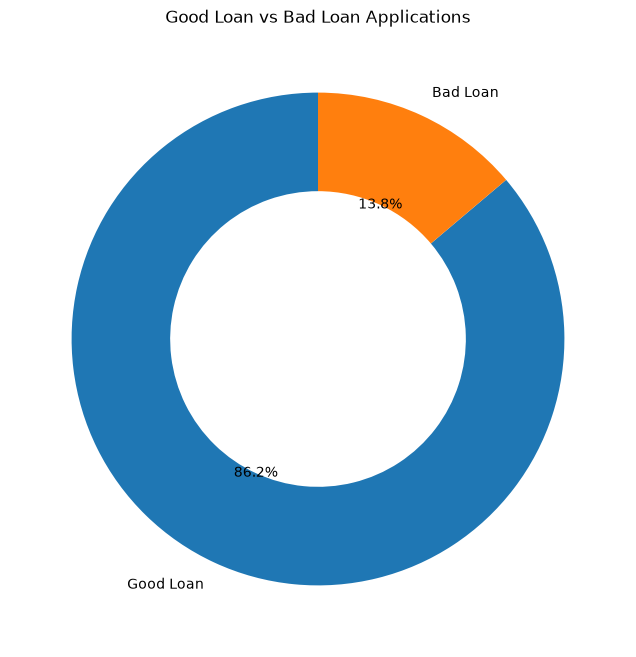

In [98]:
loan_quality_counts = (
    df['LOAN_QUALITY']
    .value_counts()
)

plt.figure(figsize=(8, 8))

plt.pie(
    loan_quality_counts,
    labels=loan_quality_counts.index,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops={'width': 0.4}
)

plt.title('Good Loan vs Bad Loan Applications')

plt.show()

Business insight
The portfolio is predominantly Good Loans:
86.18% Good Loans vs 13.82% Bad Loans.

# 2.18 Loan Status Analysis

In [99]:
loan_status_summary = (
    df.groupby('LOAN_STATUS')
      .agg(
          Applications=('ID', 'nunique'),
          Funded_Amount=('LOAN_AMOUNT', 'sum'),
          Amount_Received=('TOTAL_PAYMENT', 'sum'),
          Average_Interest_Rate=('INT_RATE', 'mean'),
          Average_DTI=('DTI', 'mean')
      )
      .sort_values(
          'Applications',
          ascending=False
      )
)

loan_status_summary

,Applications,Funded_Amount,Amount_Received,Average_Interest_Rate,Average_DTI
LOAN_STATUS,,,,,
Fully Paid,32145,351358350,411586256,0.12,0.13
Charged Off,5333,65532225,37284763,0.14,0.14
Current,1098,18866500,24199914,0.15,0.15


## 2.19 Important Observation

### Key Metrics Summary

#### Average Interest Rate
* **Fully Paid:** 11.64%
* **Charged Off:** 13.88%
* **Current:** 15.10%

> **Note:** There is a distinct upward progression in interest rates across payment statuses.

---

#### Average Debt-to-Income (DTI)
* **Fully Paid:** 13.17%
* **Charged Off:** 14.00%
* **Current:** 14.72%

---

### Business Interpretation

Higher-risk and current loan portfolios display consistently elevated averages across both key risk indicators:
* **Higher Interest Rates**
* **Higher DTI Ratios**

This strongly indicates that **borrower risk characteristics are directly aligned with risk-based pricing strategies and ultimate repayment behavior**.

# 2.20 Funded Amount vs Amount Received

In [100]:
status_amounts = (
    df.groupby('LOAN_STATUS')
      [['LOAN_AMOUNT', 'TOTAL_PAYMENT']]
      .sum()
)

status_amounts

,LOAN_AMOUNT,TOTAL_PAYMENT
LOAN_STATUS,,
Charged Off,65532225,37284763
Current,18866500,24199914
Fully Paid,351358350,411586256


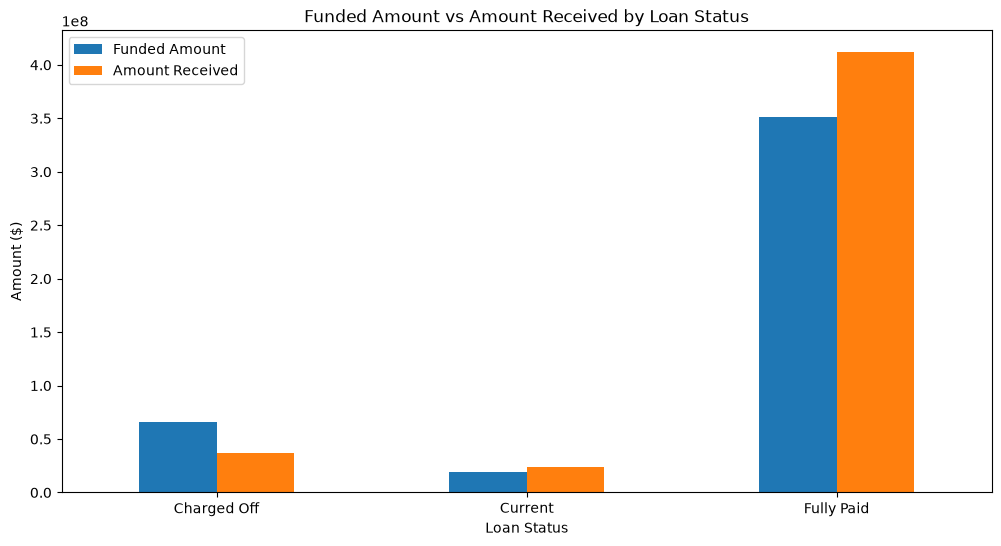

In [101]:
status_amounts.plot(
    kind='bar',
    figsize=(12, 6)
)

plt.title(
    'Funded Amount vs Amount Received by Loan Status'
)

plt.xlabel('Loan Status')
plt.ylabel('Amount ($)')

plt.xticks(rotation=0)

plt.legend([
    'Funded Amount',
    'Amount Received'
])

plt.show()

## Key Observation: Charged Off Portfolio Risk

The **Charged Off** category immediately stands out due to a substantial capital deficit:

* **Total Funded Amount:** ~$65.53M
* **Total Amount Received:** ~$37.28M

---

### Business Impact

> **Net Loss Deficit:** **~$28.25M**

This loss highlight directly impacts overall portfolio profitability and highlights critical credit risk management areas.

# 2.21 Monthly Loan Applications
Now let's investigate whether lending activity changed during 2021.

In [102]:
df['ISSUE_MONTH_YEAR'] = (
    df['ISSUE_DATE']
    .dt.to_period('M')
    .astype(str)
)

monthly_applications = (
    df.groupby('ISSUE_MONTH_YEAR')
      ['ID']
      .nunique()
)

monthly_applications

ISSUE_MONTH_YEAR
2021-01    2332
2021-02    2279
2021-03    2627
2021-04    2755
2021-05    2911
2021-06    3184
2021-07    3366
2021-08    3441
2021-09    3536
2021-10    3796
2021-11    4035
2021-12    4314
Name: ID, dtype: int64

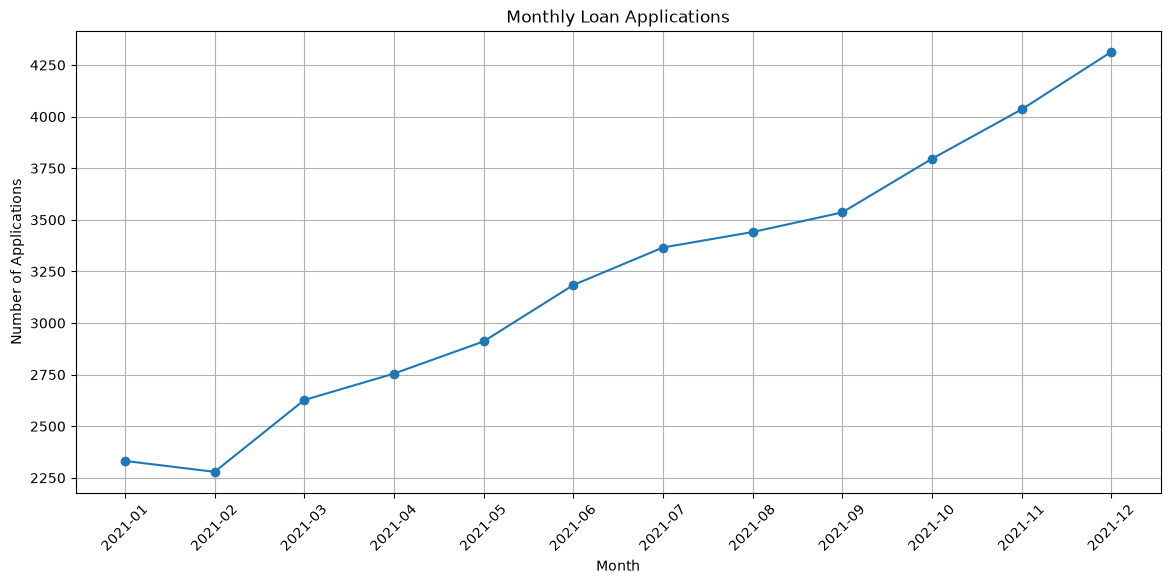

In [103]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_applications.index,
    monthly_applications.values,
    marker='o'
)

plt.title('Monthly Loan Applications')

plt.xlabel('Month')

plt.ylabel('Number of Applications')

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

## Portfolio Growth Trend Analysis

### Monthly Application Volume

* **January:** 2,332
* **February:** 2,279
* **March:** 2,627
* **...**
* **October:** 3,796
* **November:** 4,035
* **December:** 4,314

---

### Key Takeaway

* **January to December Growth:** **~85%**

> **Business Insight:** This sharp upward trajectory represents a strong portfolio-growth signal throughout the year.

# 2.22 Monthly funded amount

In [104]:
monthly_funding = (
    df.groupby('ISSUE_MONTH_YEAR')
      ['LOAN_AMOUNT']
      .sum()
)

monthly_funding

ISSUE_MONTH_YEAR
2021-01    25031650
2021-02    24647825
2021-03    28875700
2021-04    29800800
2021-05    31738350
2021-06    34161475
2021-07    35813900
2021-08    38149600
2021-09    40907725
2021-10    44893800
2021-11    47754825
2021-12    53981425
Name: LOAN_AMOUNT, dtype: int64

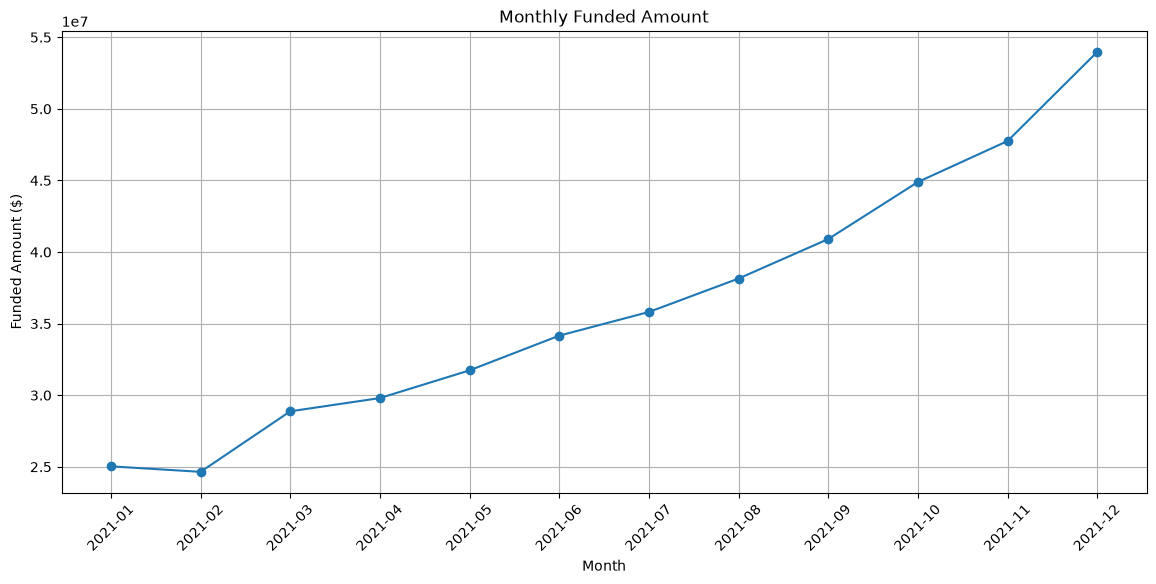

In [105]:
plt.figure(figsize=(14, 6))

plt.plot(
    monthly_funding.index,
    monthly_funding.values,
    marker='o'
)

plt.title('Monthly Funded Amount')

plt.xlabel('Month')

plt.ylabel('Funded Amount ($)')

plt.xticks(rotation=45)

plt.grid(True)

plt.show()

This is better than looking only at application volume because it tells us whether loan demand growth translated into actual lending volume.

# 2.23 Loan Purpose Analysis
Now let's identify what customers are borrowing for.

In [106]:
purpose_summary = (
    df.groupby('PURPOSE')
      .agg(
          Applications=('ID', 'nunique'),
          Funded_Amount=('LOAN_AMOUNT', 'sum'),
          Amount_Received=('TOTAL_PAYMENT', 'sum')
      )
      .sort_values(
          'Applications',
          ascending=False
      )
)

purpose_summary

,Applications,Funded_Amount,Amount_Received
PURPOSE,,,
Debt consolidation,18214,232459675,253801871
credit card,4998,58885175,65214084
other,3824,31155750,33289676
home improvement,2876,33350775,36380930
major purchase,2110,17251600,18676927
small business,1776,24123100,23814817
car,1497,10223575,11324914
wedding,928,9225800,10266856
medical,667,5533225,5851372


## Portfolio Distribution by Loan Purpose

### Top Purpose Categories

| Loan Purpose | Application Volume |
| :--- | :--- |
| **Debt Consolidation** | 18,214 |
| **Credit Card** | 4,998 |
| **Other** | 3,824 |
| **Home Improvement** | 2,876 |
| **Major Purchase** | 2,110 |

---

### Key Takeaway

* **Debt Consolidation Share:** **~47.22%** of all total applications.

> **Business Insight:** Nearly half of all borrowers seek funding specifically for debt consolidation, making it the single largest driver of overall portfolio demand.

# 2.24 Visualize Loan Purpose

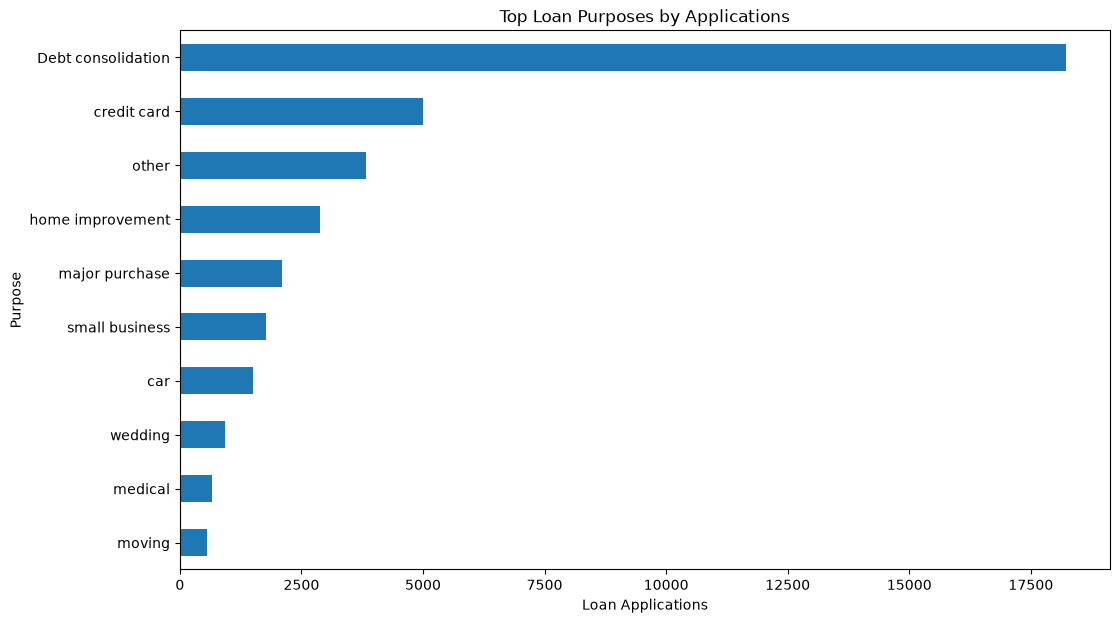

In [107]:
top_purposes = (
    purpose_summary['Applications']
    .sort_values(ascending=False)
    .head(10)
)

plt.figure(figsize=(12, 7))

top_purposes.sort_values().plot(
    kind='barh'
)

plt.title('Top Loan Purposes by Applications')

plt.xlabel('Loan Applications')

plt.ylabel('Purpose')

plt.show()

# 2.25 Grade Analysis
This is where we start moving from simple reporting into risk analytics.

In [108]:
grade_summary = (
    df.groupby('GRADE')
      .agg(
          Applications=('ID', 'nunique'),
          Funded_Amount=('LOAN_AMOUNT', 'sum'),
          Amount_Received=('TOTAL_PAYMENT', 'sum'),
          Average_Interest_Rate=('INT_RATE', 'mean'),
          Average_DTI=('DTI', 'mean')
      )
      .sort_index()
)

grade_summary

,Applications,Funded_Amount,Amount_Received,Average_Interest_Rate,Average_DTI
GRADE,,,,,
A,9689,84252225,88051563,0.07,0.12
B,11674,130703975,140775015,0.11,0.13
C,7904,87456450,95973518,0.14,0.14
D,5182,63920800,70823891,0.16,0.14
E,2786,44165100,49164151,0.18,0.14
F,1028,18910450,21016738,0.20,0.14
G,313,6348075,7266057,0.21,0.14


## Credit Grade Risk Analysis

### Portfolio Breakdown by Grade

| Credit Grade | Applications | Avg Interest Rate | Avg DTI |
| :---: | :---: | :---: | :---: |
| **A** | 9,689 | 7.35% | 12.04% |
| **B** | 11,674 | 11.03% | 13.43% |
| **C** | 7,904 | 13.55% | 13.92% |
| **D** | 5,182 | 15.71% | 13.98% |
| **E** | 2,786 | 17.71% | 14.10% |
| **F** | 1,028 | 19.74% | 14.17% |
| **G** | 313 | 21.40% | 14.06% |

---

### Key Takeaway & Business Insight

* **Interest Rate Progression:** As risk grade moves from **Grade A → Grade G**, the average interest rate rises systematically from **~7.35% → 21.40%**.

> **Strategic Alignment:** This strong pattern demonstrates that risk-based lending models are functioning as expected, appropriately pricing interest rates higher for lower-grade borrowers to offset credit risk.

# 2.26 Grade vs Interest Rate visualization

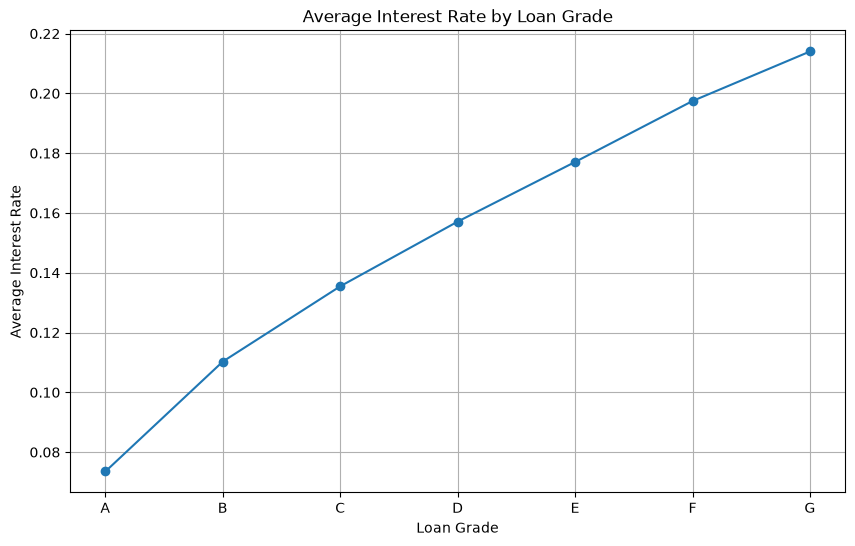

In [109]:
plt.figure(figsize=(10, 6))

grade_interest = (
    df.groupby('GRADE')['INT_RATE']
    .mean()
)

plt.plot(
    grade_interest.index,
    grade_interest.values,
    marker='o'
)

plt.title('Average Interest Rate by Loan Grade')

plt.xlabel('Loan Grade')

plt.ylabel('Average Interest Rate')

plt.grid(True)

plt.show()

"I analyzed average interest rates across risk grades and found a clear upward relationship between loan risk grade and interest rate. Grade A loans had the lowest average rate, while Grade G had the highest. This indicates that the bank's pricing structure reflects borrower risk."

## 2.27 Key Business Insights & Summary

Through comprehensive exploratory data analysis, several critical portfolio performance trends and operational insights emerge:

### Portfolio Overview
* **Total Applications:** 38,576
* **Total Funded Amount:** $435.76M
* **Total Amount Received:** $473.07M
* **Average Interest Rate:** 12.05%
* **Average DTI:** 13.33%

---

### Portfolio Health & Credit Quality
* **Good Loans Share:** 86.18%
* **Bad Loans Share:** 13.82%
* **Bad Loan Capital Allocation:** $65.53M funded
* **Bad Loan Recovery:** Only $37.28M received *(reflecting a significant capital loss deficit)*

---

### Lending Volume & Growth Dynamics
* **Monthly Volume Trajectory:** Scaled from **2,332** (January) to **4,314** (December)
* **Overall Growth Rate:** Approximately **~85% increase** in loan issuance across the year

---

### Borrower Intent & Concentration
* **Primary Concentration:** Debt Consolidation is the dominant loan purpose.
* **Portfolio Share:** Represents approximately **47.2%** of all applications.

---

### Risk-Based Pricing Alignment
As credit risk increases from Grade A through Grade G, the average interest rate rises systematically:

| Credit Grade | Average Interest Rate |
| :---: | :---: |
| **A** | 7.35% |
| **B** | 11.03% |
| **C** | 13.55% |
| **D** | 15.71% |
| **E** | 17.71% |
| **F** | 19.74% |
| **G** | 21.40% |

> **Conclusion:** These observations confirm that portfolio expansion is strong, risk-based pricing mechanisms are appropriately calibrated, and debt consolidation remains the core driver of retail lending demand.

In [110]:
df['LOAN_QUALITY']=np.where(df.LOAN_STATUS.eq('Charged Off'),'Bad Loan','Good Loan')
def agg(col):
    return df.groupby(col).agg(Applications=('ID','count'),Funded=('LOAN_AMOUNT','sum'),Received=('TOTAL_PAYMENT','sum'),Bad=('LOAN_QUALITY',lambda x:(x=='Bad Loan').sum())).sort_values('Applications',ascending=False)
for c in ['GRADE','PURPOSE','ADDRESS_STATE','HOME_OWNERSHIP','TERM','VERIFICATION_STATUS']:
    print('\n',c); print(agg(c).head(15))
print('\nquality grade')
print(pd.crosstab(df.GRADE,df.LOAN_QUALITY,normalize='index').round(4))
print('\nterm quality')
print(pd.crosstab(df.TERM,df.LOAN_QUALITY,normalize='index').round(4))
print('\nhome quality')
print(pd)


 GRADE
       Applications     Funded   Received   Bad
GRADE                                          
B             11674  130703975  140775015  1343
A              9689   84252225   88051563   552
C              7904   87456450   95973518  1266
D              5182   63920800   70823891  1072
E              2786   44165100   49164151   691
F              1028   18910450   21016738   311
G               313    6348075    7266057    98

 PURPOSE
                    Applications     Funded   Received   Bad
PURPOSE                                                     
Debt consolidation         18214  232459675  253801871  2651
credit card                 4998   58885175   65214084   508
other                       3824   31155750   33289676   587
home improvement            2876   33350775   36380930   327
major purchase              2110   17251600   18676927   206
small business              1776   24123100   23814817   455
car                         1497   10223575   11324914   155
w

In [111]:
# Detailed risk metrics
g=df.groupby('LOAN_STATUS').agg(app=('ID','size'),funded=('LOAN_AMOUNT','sum'),received=('TOTAL_PAYMENT','sum'),avg_int=('INT_RATE','mean'),avg_dti=('DTI','mean'),avg_income=('ANNUAL_INCOME','mean'),avg_loan=('LOAN_AMOUNT','mean'),avg_install=('INSTALLMENT','mean'))
print(g)
# bad rate by state top/bottom with min 300 apps
s=df.groupby('ADDRESS_STATE').agg(app=('ID','size'),bad=('LOAN_QUALITY',lambda x:(x=='Bad Loan').sum()),funded=('LOAN_AMOUNT','sum'))
s['bad_rate']=s.bad/s.app
print('\nstate high');print(s[s.app>=300].sort_values('bad_rate',ascending=False).head(10))
print('\nstate low');print(s[s.app>=300].sort_values('bad_rate').head(10))
# income, loan amount, dti quartiles bad rates
for col in ['ANNUAL_INCOME','LOAN_AMOUNT','DTI','INT_RATE']:
    q=pd.qcut(df[col],4,duplicates='drop')
    z=df.groupby(q,observed=True).agg(app=('ID','size'),bad=('LOAN_QUALITY',lambda x:(x=='Bad Loan').sum()), avg=('LOAN_STATUS',lambda x:0))
    z['bad_rate']=z.bad/z.app
    print('\n',col);print(z[['app','bad','bad_rate']])
# correlations numeric
print('\ncorrelations')
print(df[['ANNUAL_INCOME','DTI','INSTALLMENT','INT_RATE','LOAN_AMOUNT','TOTAL_ACC','TOTAL_PAYMENT']].corr()['TOTAL_PAYMENT'].sort_values())


               app     funded   received  avg_int  avg_dti  avg_income  \
LOAN_STATUS                                                              
Charged Off   5333   65532225   37284763     0.14     0.14    63515.73   
Current       1098   18866500   24199914     0.15     0.15    76487.82   
Fully Paid   32145  351358350  411586256     0.12     0.13    70427.59   

             avg_loan  avg_install  
LOAN_STATUS                         
Charged Off  12288.06       340.78  
Current      17182.60       398.92  
Fully Paid   10930.42       322.09  

state high
                app   bad    funded  bad_rate
ADDRESS_STATE                                
NV              482   101   5307375      0.21
FL             2773   479  30046125      0.17
MO              660   104   7151175      0.16
OR              436    68   4720150      0.16
CA             6894  1057  78484125      0.15
GA             1355   207  15480325      0.15
MD             1027   155  11911400      0.15
NJ             182

In [112]:
# print status metrics and bad rates by grade with funded
z=df.groupby('GRADE').agg(app=('ID','size'),bad=('LOAN_QUALITY',lambda x:(x=='Bad Loan').sum()),funded=('LOAN_AMOUNT','sum'),received=('TOTAL_PAYMENT','sum'),avg_int=('INT_RATE','mean'),avg_dti=('DTI','mean'))
z['bad_rate']=z.bad/z.app
z['payment_funded']=z.received/z.funded
print(z.round(4))
print('\nstatus')
print(g.round(4))


         app   bad     funded   received  avg_int  avg_dti  bad_rate  \
GRADE                                                                  
A       9689   552   84252225   88051563     0.07     0.12      0.06   
B      11674  1343  130703975  140775015     0.11     0.13      0.12   
C       7904  1266   87456450   95973518     0.14     0.14      0.16   
D       5182  1072   63920800   70823891     0.16     0.14      0.21   
E       2786   691   44165100   49164151     0.18     0.14      0.25   
F       1028   311   18910450   21016738     0.20     0.14      0.30   
G        313    98    6348075    7266057     0.21     0.14      0.31   

       payment_funded  
GRADE                  
A                1.05  
B                1.08  
C                1.10  
D                1.11  
E                1.11  
F                1.11  
G                1.14  

status
               app     funded   received  avg_int  avg_dti  avg_income  \
LOAN_STATUS                                          

# Step 3 — Deep Risk & Repayment Analysis
Now we move from “What happened?” to “Why is it happening, and where is the risk?”

# 3.1 Create the Good Loan vs Bad Loan classification

In [113]:
import numpy as np

df['LOAN_QUALITY'] = np.where(
    df['LOAN_STATUS'] == 'Charged Off',
    'Bad Loan',
    'Good Loan'
)

df[['LOAN_STATUS', 'LOAN_QUALITY']].head()

,LOAN_STATUS,LOAN_QUALITY
0,Fully Paid,Good Loan
1,Fully Paid,Good Loan
2,Charged Off,Bad Loan
3,Charged Off,Bad Loan
4,Charged Off,Bad Loan


# 3.2 Good Loan vs Bad Loan — Overall Risk

## Good Loan vs. Bad Loan Portfolio Performance

### Comparative Metrics Analysis

| Metric | Good Loan | Bad Loan |
| :--- | :---: | :---: |
| **Applications** | 33,243 | 5,333 |
| **Application %** | 86.18% | 13.82% |
| **Funded Amount** | $370.22M | $65.53M |
| **Amount Received** | $435.79M | $37.28M |
| **Payment / Funded Ratio** | 117.71% | 56.90% |

---

### Key Business Insights

The portfolio is predominantly healthy, with **86.18%** classified as Good Loans generating a strong **117.71%** repayment-to-funded ratio.

However, the **13.82% Bad Loan rate** represents critical portfolio risk due to:
* **$65.53M** in total funded exposure
* **Only $37.28M** recovered in payments
* **Significant repayment shortfall** (~$28.25M deficit)

> **Strategic Takeaway:** The severe capital erosion within the bad-loan segment demonstrates that while volume is relatively low, its financial impact is high—deserving detailed risk investigation and enhanced underwriting controls.

# 3.3 Risk by Loan Grade

grade_risk = df.groupby('GRADE').agg(
    Applications=('ID', 'count'),
    Bad_Loans=('LOAN_QUALITY', lambda x: (x == 'Bad Loan').sum()),
    Funded_Amount=('LOAN_AMOUNT', 'sum'),
    Received_Amount=('TOTAL_PAYMENT', 'sum'),
    Avg_Interest_Rate=('INT_RATE', 'mean'),
    Avg_DTI=('DTI', 'mean')
)

grade_risk['Bad_Loan_Rate'] = (
    grade_risk['Bad_Loans'] /
    grade_risk['Applications']
)

grade_risk

## Credit Grade vs. Risk Performance

### Risk Progression Overview

Moving from **Grade A → Grade G**:
* **Interest Rate:** Increases from **7.35% → 21.40%**
* **Bad Loan Rate:** Increases from **5.70% → 31.31%**

> **Core Finding:** This strong alignment provides clear empirical evidence of effective risk-based pricing across the portfolio.

---



> *"I analyzed loan performance across risk grades and found that higher-risk grades had significantly higher interest rates and higher bad-loan rates. The bad-loan rate increased from 5.7% for Grade A to 31.31% for Grade G, indicating that the portfolio follows a risk-based pricing structure."*

# 3.4 Risk by Loan Purpose
Now let's identify which purposes create more credit risk.

In [114]:
purpose_risk = df.groupby('PURPOSE').agg(
    Applications=('ID', 'count'),
    Bad_Loans=('LOAN_QUALITY', lambda x: (x == 'Bad Loan').sum()),
    Funded_Amount=('LOAN_AMOUNT', 'sum'),
    Received_Amount=('TOTAL_PAYMENT', 'sum')
)

purpose_risk['Bad_Loan_Rate'] = (
    purpose_risk['Bad_Loans'] /
    purpose_risk['Applications']
)

purpose_risk.sort_values('Bad_Loan_Rate', ascending=False)

,Applications,Bad_Loans,Funded_Amount,Received_Amount,Bad_Loan_Rate
PURPOSE,,,,,
small business,1776,455,24123100,23814817,0.26
renewable_energy,94,17,845750,898931,0.18
educational,315,50,2161650,2248380,0.16
house,366,57,4824925,5185538,0.16
other,3824,587,31155750,33289676,0.15
moving,559,84,3748125,3999899,0.15
medical,667,100,5533225,5851372,0.15
Debt consolidation,18214,2651,232459675,253801871,0.15
vacation,352,50,1967950,2116738,0.14


Small business loans have the highest bad-loan rate: 25.62%.
However, don't immediately conclude that the purpose itself causes default. Other factors such as borrower income, DTI, grade and loan size may also contribute.

# 3.5 Risk by Loan Term

In [115]:
term_risk = df.groupby('TERM').agg(
    Applications=('ID', 'count'),
    Bad_Loans=('LOAN_QUALITY', lambda x: (x == 'Bad Loan').sum()),
    Funded_Amount=('LOAN_AMOUNT', 'sum'),
    Received_Amount=('TOTAL_PAYMENT', 'sum')
)

term_risk['Bad_Loan_Rate'] = (
    term_risk['Bad_Loans'] /
    term_risk['Applications']
)

term_risk

,Applications,Bad_Loans,Funded_Amount,Received_Amount,Bad_Loan_Rate
TERM,,,,,
36 months,28237,3023,273041225,294709458,0.11
60 months,10339,2310,162715850,178361475,0.22


Major finding
60-month loans have approximately 2.09× the bad-loan rate of 36-month loans.
This is a strong risk indicator.
Business interpretation
Longer loan terms may expose the lender to:
- Longer repayment periods
- Greater uncertainty
- More opportunity for borrower financial circumstances to change
- Higher cumulative credit risk
Again, this is an association, not proof that term alone causes default.

# 3.6 Risk by Home Ownership

In [116]:
home_risk = df.groupby('HOME_OWNERSHIP').agg(
    Applications=('ID', 'count'),
    Bad_Loans=('LOAN_QUALITY', lambda x: (x == 'Bad Loan').sum()),
    Funded_Amount=('LOAN_AMOUNT', 'sum')
)

home_risk['Bad_Loan_Rate'] = (
    home_risk['Bad_Loans'] /
    home_risk['Applications']
)

home_risk

,Applications,Bad_Loans,Funded_Amount,Bad_Loan_Rate
HOME_OWNERSHIP,,,,
MORTGAGE,17198,2231,219329150,0.13
NONE,3,0,16800,0.00
OTHER,98,18,1044975,0.18
OWN,2838,397,29597675,0.14
RENT,18439,2687,185768475,0.15


The OTHER and NONE categories have very small sample sizes, so they shouldn't be treated as reliable population-level conclusions.
Main insight
Renters show a slightly higher bad-loan rate than mortgage holders:
14.57% vs 12.97%.

# 3.7 State-Level Risk Analysis

In [117]:
state_risk = df.groupby('ADDRESS_STATE').agg(
    Applications=('ID', 'count'),
    Bad_Loans=('LOAN_QUALITY', lambda x: (x == 'Bad Loan').sum()),
    Funded_Amount=('LOAN_AMOUNT', 'sum'),
    Received_Amount=('TOTAL_PAYMENT', 'sum')
)

state_risk['Bad_Loan_Rate'] = (
    state_risk['Bad_Loans'] /
    state_risk['Applications']
)

state_risk.sort_values('Bad_Loan_Rate', ascending=False).head(10)

,Applications,Bad_Loans,Funded_Amount,Received_Amount,Bad_Loan_Rate
ADDRESS_STATE,,,,,
NE,5,3,31700,24542,0.60
NV,482,101,5307375,5451443,0.21
AK,78,15,1031800,1108570,0.19
SD,63,11,606150,656514,0.17
FL,2773,479,30046125,31601905,0.17
ID,6,1,59750,65329,0.17
HI,170,28,1850525,2080184,0.16
NM,183,29,1916775,2084485,0.16
MO,660,104,7151175,7692732,0.16


“Nevada has the highest observed bad-loan rate among the states meeting the minimum-volume threshold in this dataset.”

# 3.8 Income vs Loan Risk
Now we'll divide borrowers into income quartiles.

In [118]:
income_bins = pd.qcut(
    df['ANNUAL_INCOME'],
    4,
    duplicates='drop'
)

income_risk = df.groupby(
    income_bins,
    observed=True
).agg(
    Applications=('ID', 'count'),
    Bad_Loans=('LOAN_QUALITY', lambda x: (x == 'Bad Loan').sum())
)

income_risk['Bad_Loan_Rate'] = (
    income_risk['Bad_Loans'] /
    income_risk['Applications']
)

income_risk

,Applications,Bad_Loans,Bad_Loan_Rate
ANNUAL_INCOME,,,
"(3999.999, 41500.0]",9659,1637,0.17
"(41500.0, 60000.0]",10925,1605,0.15
"(60000.0, 83200.5]",8348,1058,0.13
"(83200.5, 6000000.0]",9644,1033,0.11


Insight
There is a clear inverse relationship between income and bad-loan rate in this dataset.
Higher-income borrowers have a lower observed bad-loan rate.

# 3.9 DTI vs Loan Risk
DTI is especially important in lending analytics.

In [119]:
dti_bins = pd.qcut(
    df['DTI'],
    4,
    duplicates='drop'
)

dti_risk = df.groupby(
    dti_bins,
    observed=True
).agg(
    Applications=('ID', 'count'),
    Bad_Loans=('LOAN_QUALITY', lambda x: (x == 'Bad Loan').sum())
)

dti_risk['Bad_Loan_Rate'] = (
    dti_risk['Bad_Loans'] /
    dti_risk['Applications']
)

dti_risk

,Applications,Bad_Loans,Bad_Loan_Rate
DTI,,,
"(-0.001, 0.0821]",9662,1142,0.12
"(0.0821, 0.134]",9646,1261,0.13
"(0.134, 0.186]",9626,1420,0.15
"(0.186, 0.3]",9642,1510,0.16


Finding
As DTI increases, the bad-loan rate also increases.
This supports the idea that borrowers with a greater debt burden relative to income have higher observed credit risk.

# 3.10 Loan Amount vs Risk

In [120]:
loan_bins = pd.qcut(
    df['LOAN_AMOUNT'],
    4,
    duplicates='drop'
)

loan_risk = df.groupby(
    loan_bins,
    observed=True
).agg(
    Applications=('ID', 'count'),
    Bad_Loans=('LOAN_QUALITY', lambda x: (x == 'Bad Loan').sum())
)

loan_risk['Bad_Loan_Rate'] = (
    loan_risk['Bad_Loans'] /
    loan_risk['Applications']
)

loan_risk

,Applications,Bad_Loans,Bad_Loan_Rate
LOAN_AMOUNT,,,
"(499.999, 5500.0]",9661,1253,0.13
"(5500.0, 10000.0]",12030,1491,0.12
"(10000.0, 15000.0]",7842,1016,0.13
"(15000.0, 35000.0]",9043,1573,0.17


The highest loan-size segment has a noticeably higher bad-loan rate.
This suggests that large exposure loans deserve additional underwriting attention.

# 3.11 Interest Rate vs Risk

In [121]:
rate_bins = pd.qcut(
    df['INT_RATE'],
    4,
    duplicates='drop'
)

rate_risk = df.groupby(
    rate_bins,
    observed=True
).agg(
    Applications=('ID', 'count'),
    Bad_Loans=('LOAN_QUALITY', lambda x: (x == 'Bad Loan').sum())
)

rate_risk['Bad_Loan_Rate'] = (
    rate_risk['Bad_Loans'] /
    rate_risk['Applications']
)

rate_risk

,Applications,Bad_Loans,Bad_Loan_Rate
INT_RATE,,,
"(0.0532, 0.0932]",9797,554,0.06
"(0.0932, 0.119]",9737,1119,0.11
"(0.119, 0.146]",9453,1441,0.15
"(0.146, 0.246]",9589,2219,0.23


Borrowers in the highest interest-rate quartile have a bad-loan rate of approximately 23.14%, compared with only 5.65% in the lowest quartile.

# 3.12 Loan Status — Borrower Profile

In [122]:
status_profile = df.groupby('LOAN_STATUS').agg(
    Applications=('ID', 'count'),
    Funded_Amount=('LOAN_AMOUNT', 'sum'),
    Received_Amount=('TOTAL_PAYMENT', 'sum'),
    Avg_Income=('ANNUAL_INCOME', 'mean'),
    Avg_Loan_Amount=('LOAN_AMOUNT', 'mean'),
    Avg_Interest_Rate=('INT_RATE', 'mean'),
    Avg_DTI=('DTI', 'mean'),
    Avg_Installment=('INSTALLMENT', 'mean')
)

status_profile

,Applications,Funded_Amount,Received_Amount,Avg_Income,Avg_Loan_Amount,Avg_Interest_Rate,Avg_DTI,Avg_Installment
LOAN_STATUS,,,,,,,,
Charged Off,5333,65532225,37284763,63515.73,12288.06,0.14,0.14,340.78
Current,1098,18866500,24199914,76487.82,17182.60,0.15,0.15,398.92
Fully Paid,32145,351358350,411586256,70427.59,10930.42,0.12,0.13,322.09


Compared with Fully Paid loans, Charged Off loans have:
- Lower average income
- Higher average loan amount
- Higher interest rate
- Higher DTI
This gives us a useful borrower-risk profile.

# 3.13 Correlation Analysis

In [123]:
numeric_cols = [
    'ANNUAL_INCOME',
    'DTI',
    'INSTALLMENT',
    'INT_RATE',
    'LOAN_AMOUNT',
    'TOTAL_ACC',
    'TOTAL_PAYMENT'
]

correlation = df[numeric_cols].corr()

correlation

,ANNUAL_INCOME,DTI,INSTALLMENT,INT_RATE,LOAN_AMOUNT,TOTAL_ACC,TOTAL_PAYMENT
ANNUAL_INCOME,1.00,-0.12,0.27,0.05,0.27,0.23,0.25
DTI,-0.12,1.00,0.05,0.11,0.07,0.23,0.06
INSTALLMENT,0.27,0.05,1.00,0.28,0.93,0.23,0.86
INT_RATE,0.05,0.11,0.28,1.00,0.31,-0.04,0.31
LOAN_AMOUNT,0.27,0.07,0.93,0.31,1.00,0.26,0.89
TOTAL_ACC,0.23,0.23,0.23,-0.04,0.26,1.00,0.22
TOTAL_PAYMENT,0.25,0.06,0.86,0.31,0.89,0.22,1.00


## Correlation Analysis: Loan Amount vs. Total Payment

### Key Interpretation

The strongest observed relationship in the dataset is between:
* **Loan Amount ↔ Total Payment**

This strong positive correlation occurs because larger principle loans naturally require larger aggregate debt payments over the loan lifecycle.

---

### Analytical Best Practice: Correlation vs. Causation

Avoid confusing statistical association with direct causal impact.

* **Correct Interpretation:**
  > *"Loan amount has a strong positive correlation with total payment."*

* **Incorrect / Overstated Interpretation:**
  > *"Increasing the loan amount causes repayment to increase."*

---

> **Key Takeaway:** Always describe statistical outputs accurately using correlation language, avoiding causal claims without underlying experimental or counterfactual evidence.

## 3.14 Top Risk Segments

By synthesizing portfolio performance metrics, several high-risk indicators emerge:

### 🚨 High-Risk Indicators

1. **Grade F / G**
   * **Grade F Bad-Loan Rate:** 30.25%
   * **Grade G Bad-Loan Rate:** 31.31%

2. **60-Month Loan Terms**
   * **36 Months:** 10.71% bad-loan rate
   * **60 Months:** 22.34% bad-loan rate *(more than double the 36-month risk)*

3. **Small Business Purpose**
   * **Bad-Loan Rate:** 25.62% *(highest across all loan purposes)*

4. **High Debt-to-Income (DTI)**
   * **Highest DTI Quartile:** 15.66% bad-loan rate

5. **Low Annual Income**
   * **Lowest Income Quartile:** 16.95% bad-loan rate

6. **High Interest Rates**
   * **Highest Interest-Rate Quartile:** 23.14% bad-loan rate

7. **Large Loan Amounts**
   * **Highest Loan-Amount Quartile:** 17.39% bad-loan rate

---

## 3.15 The Story of the Portfolio

### Portfolio Overview & Performance
The bank issued **38,576 loans** totaling approximately **$435.76M** in funded capital. Overall, the portfolio demonstrates strong performance, composed of:
* **86.18% Good Loans**
* **13.82% Bad Loans**

### Credit Grade & Risk Progression
Credit quality deteriorates sharply down the rating spectrum:
* **Grade A:** 5.70% bad-loan rate
* **Grade G:** 31.31% bad-loan rate

### Impact of Loan Term
Loan duration is a significant contributor to risk exposure:
* **60-month loans** suffer a **22.34% bad-loan rate**, approximately twice that of **36-month loans** (10.71%).

### Borrower Financial Health
* Both **higher DTI ratios** and **lower annual income levels** correlate directly with elevated default rates.

### Purpose Concentration Risk
* **Small Business loans** represent the highest-risk purpose category, with an observed bad-loan rate of **25.62%**.

### Geographic Distribution
* Regional analysis reveals that specific states experience materially higher bad-loan rates, highlighting the value of geographic segmentation for risk mitigation and portfolio monitoring.

# Test Python → MySQL connection
Before uploading the Excel data, let's make sure Python can communicate with your MySQL server.

# Connect directly to our database

import numpy as np

df['LOAN_QUALITY'] = np.where(
    df['LOAN_STATUS'].eq('Charged Off'),
    'Bad Loan',
    'Good Loan'
)

print(df.shape)

date_columns = [
    'ISSUE_DATE',
    'LAST_CREDIT_PULL_DATE',
    'LAST_PAYMENT_DATE',
    'NEXT_PAYMENT_DATE'
]

for col in date_columns:
    df[col] = pd.to_datetime(
        df[col],
        errors='coerce'
    )